In [1]:
# https://github.com/eclique/RISE/blob/master/explanations.py

from utils.cub_config import Config
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
from torchvision import models, transforms
import cv2 
from skimage.transform import resize
import matplotlib.pyplot as plt
import os
from utils.cub_config import Config

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

Usando dispositivo: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [4]:
class RISE(nn.Module):
    def __init__(self, model, input_size, gpu_batch=10):
        super(RISE, self).__init__()
        self.model = model
        self.input_size = input_size
        self.gpu_batch = gpu_batch
    
    def generate_masks(self, N, s, p1, savepath='masks.npy'):
        from skimage.transform import resize
        
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size
        grid = np.random.rand(N, s, s) < p1
        grid = grid.astype('float32')
        self.masks = np.empty((N, *self.input_size))
        
        for i in tqdm(range(N), desc='Generating filters'):
            x = np.random.randint(0, cell_size[0])
            y = np.random.randint(0, cell_size[1])
            self.masks[i, :, :] = resize(grid[i], up_size, order=1, mode='reflect',
                                         anti_aliasing=False)[x:x + self.input_size[0], y:y + self.input_size[1]]
        
        self.masks = self.masks.reshape(-1, 1, *self.input_size)
        np.save(savepath, self.masks)
        self.N = N
        self.p1 = p1
    
    def load_masks(self, filepath):
        self.masks = np.load(filepath)
        self.N = self.masks.shape[0]
    
    def forward(self, x):
        N = self.N
        B, C, H, W = x.size()
        
        p_list = []
        
        for i in tqdm(range(0, N, self.gpu_batch), desc='Processing masks'):
            end_idx = min(i + self.gpu_batch, N)
            
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
 
            stack = torch.mul(batch_masks, x.data)

            with torch.no_grad():
                batch_p = self.model(stack)
                p_list.append(batch_p.cpu())  
            
            del batch_masks, stack
            torch.cuda.empty_cache()
        

        p = torch.cat(p_list).to(x.device)

        CL = p.size(1)
        
        sal = torch.zeros((CL, H * W), device=x.device)
        
        for i in range(0, N, self.gpu_batch):
            end_idx = min(i + self.gpu_batch, N)
            batch_masks = torch.from_numpy(self.masks[i:end_idx]).float().to(x.device)
            batch_p = p[i:end_idx]
            
            sal += torch.matmul(batch_p.data.transpose(0, 1), 
                               batch_masks.view(end_idx - i, H * W))
            
            del batch_masks
            torch.cuda.empty_cache()
        
        sal = sal.view((CL, H, W))
        sal = sal / N / self.p1
        
        return sal

In [5]:
input_size = (448, 448)
explainer = RISE(model, input_size, gpu_batch=100)

In [ ]:
N = 3000  
s = 8     
p1 = 0.5 

print("Gerando máscaras...")
explainer.generate_masks(N=N, s=s, p1=p1, savepath='../../model/masks.npy')

Gerando máscaras...


Generating filters: 100%|██████████| 3000/3000 [00:24<00:00, 121.03it/s]


In [18]:
image_path = "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg"
img = Image.open(image_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0)

In [19]:
model = model.to(device)
input_tensor = input_tensor.to(device)

# Gerar saliency map
print("Gerando mapa de saliência...")
with torch.no_grad():
    sal = explainer(input_tensor)

# Obter a predição do modelo
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
confidence = torch.nn.functional.softmax(output, dim=1)[0, pred_class].item()

print(f"Classe predita: {pred_class}")
print(f"Confiança: {confidence:.4f}")

Gerando mapa de saliência...


Processing masks: 100%|██████████| 30/30 [06:27<00:00, 12.91s/it]


Classe predita: 26
Confiança: 0.3467


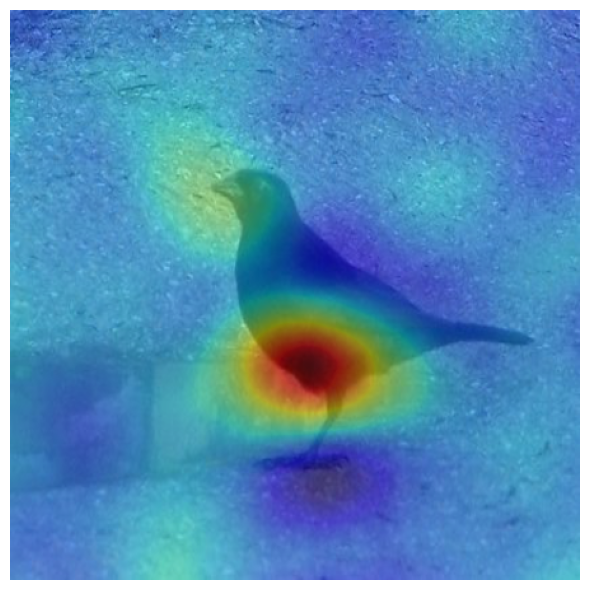

In [20]:
plt.figure(figsize=(6, 6))

# Imagem original
img_display = np.array(img)
sal_map = sal[pred_class].cpu().numpy()

raw_np = np.array(img.resize((448, 448))) / 255.0

# Overlay
plt.imshow(raw_np)
plt.imshow(sal_map, cmap='jet', alpha=0.5)
plt.axis('off')

plt.tight_layout()
img_name = os.path.basename(image_path)
path = os.path.join(Config.OUTPUT_DIR, f'rise_{img_name}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()

## AVALIAÇÃO


In [7]:
test_images = [
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0037_49068.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0118_49191.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0077_49051.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0099_49218.jpg",
]

In [9]:
heatmaps = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    model = model.to(device)
    
    with torch.no_grad():
        sal = explainer(input_tensor)

    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    confidence = torch.nn.functional.softmax(output, dim=1)[0, pred_class].item()

    sal_map = sal[pred_class].cpu().numpy()
    heatmaps.append(sal_map)

Processing masks: 100%|██████████| 30/30 [06:39<00:00, 13.31s/it]


In [10]:
from cub_eval import deletion_test

In [13]:
broke_list = []
for image_path, heatmap in zip(test_images, heatmaps):
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class}")

    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, pred_class, max_steps=3000, pixels_per_step=200)

    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Average broke: ", np.mean(broke_list))

Predicted class: 62
Broke at step: 447
Predicted class: 62
Broke at step: 3
Predicted class: 62
Broke at step: 710
Predicted class: 62
Broke at step: 923
Average broke:  520.75


Text(0.5, 1.0, 'Deletion Test')

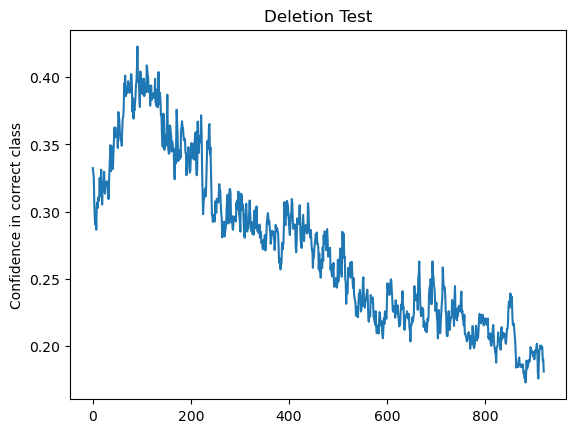

In [13]:
## plot confidences

plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')

Text(0.5, 1.0, 'Deletion Test')

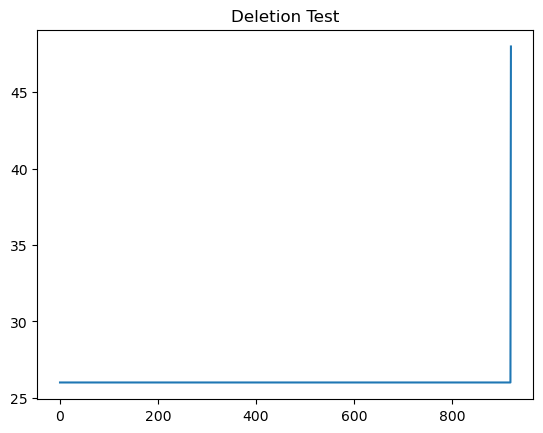

In [14]:
plt.plot(predictions)
plt.title('Deletion Test')

## ROBUSTNESS

In [14]:
from cub_eval import robustness_test

robustness_score_list = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    robustness_score = robustness_test(model,'RISE', input_tensor, explainer)
    print(f"Robustness score: {robustness_score}")
    robustness_score_list.append(robustness_score)

print("Average robustness score: ", np.mean(robustness_score_list))


Processing masks: 100%|██████████| 30/30 [05:21<00:00, 10.73s/it]


Robustness score: 0.9954317808151245


Processing masks: 100%|██████████| 30/30 [05:19<00:00, 10.65s/it]


Robustness score: 0.9841100573539734


Processing masks: 100%|██████████| 30/30 [05:33<00:00, 11.12s/it]


Robustness score: 0.9893019795417786


Processing masks: 100%|██████████| 30/30 [05:05<00:00, 10.17s/it]


Robustness score: 0.9929367303848267
Average robustness score:  0.99044514


## SPARSITY AND SPATIAL COHERENCE

In [15]:
from cub_eval import calculate_gini_index, calculate_spatial_coherence
from skimage.measure import label

gini_list = []
coherence_list = []
for heatmap in heatmaps:
    sal_map = heatmap
    gini_index = calculate_gini_index(sal_map)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)
    coherence = calculate_spatial_coherence(sal_map)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Average Gini Index: ", np.mean(gini_list))
print("Average Spatial Coherence: ", np.mean(coherence_list))

Gini Index: 0.015423444099724293
Spatial Coherence: 0.9355875253677368
Gini Index: 0.016001954674720764
Spatial Coherence: 1.0
Gini Index: 0.014055991545319557
Spatial Coherence: 1.0
Gini Index: 0.011961567215621471
Spatial Coherence: 1.0
Average Gini Index:  0.01436074
Average Spatial Coherence:  0.98389685


## INTRA-CLASS CONSISTENCY

In [20]:
test_images_26 = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg",
]

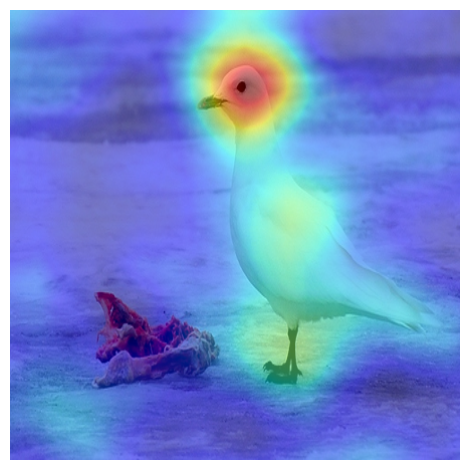

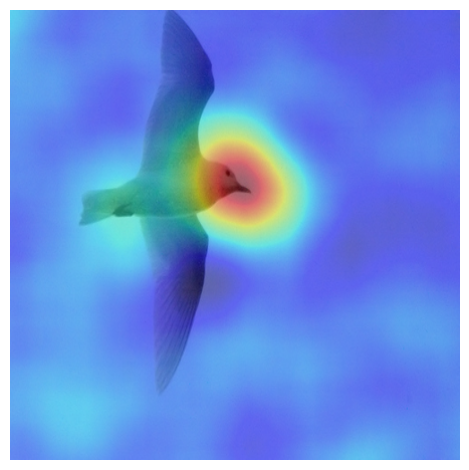

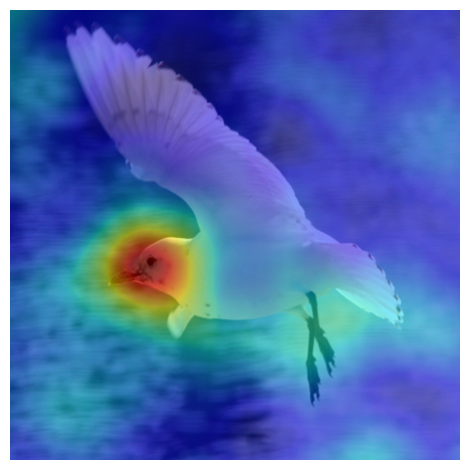

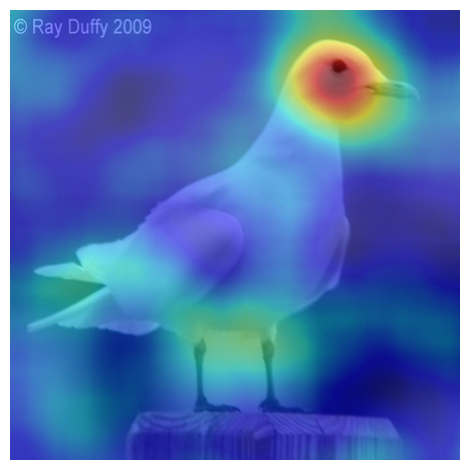

In [16]:

for heatmap, image_path in zip(heatmaps, test_images):
    img = Image.open(image_path).convert('RGB')



    raw_np = np.array(img.resize((448, 448))) / 255.0

    # Overlay
    plt.imshow(raw_np)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.axis('off')

    plt.tight_layout()
    img_name = os.path.basename(image_path)
    path = os.path.join(Config.OUTPUT_DIR, f'rise_{img_name}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    heatmaps.append(sal_map)

In [17]:
from cub_eval import intraclass_consistency

consistency = intraclass_consistency(heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.4419382788999444
